In [1]:
import cv2
import typing
import numpy as np
import matplotlib.pyplot as plt

from mltu.inferenceModel import OnnxInferenceModel
from mltu.utils.text_utils import ctc_decoder
from mltu.configs import BaseModelConfigs

In [2]:
class ImageToWordModel(OnnxInferenceModel):

    def __init__(self, char_list: typing.Union[str, list], *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.char_list = char_list

    def predict(self, image: np.ndarray):
    
        # Resize image
        image = cv2.resize(image, self.input_shape[:2][::-1])
    
        # Prepare tensor
        image_pred = np.expand_dims(image, axis=0).astype(np.float32)
    
        # ONNX inference
        preds = self.model.run(
            None,
            {self.input_name: image_pred}
        )[0]
    
        # Decode text
        text = ctc_decoder(preds, self.char_list)[0]
    
        return text

Detected Text: Words


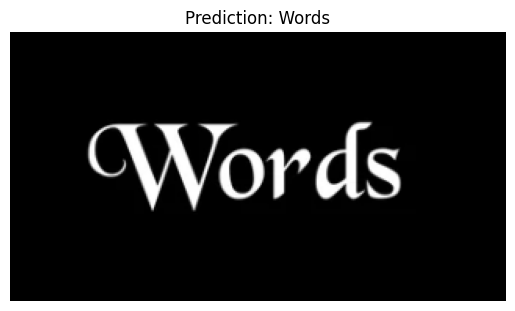

In [3]:
configs = BaseModelConfigs.load(
    "../models/202211270035/configs.yaml"
)

# FIX MODEL PATH
configs.model_path = "../models/202211270035/model.onnx"

# -----------------------------
# LOAD MODEL
# -----------------------------
model = ImageToWordModel(
    model_path=configs.model_path,
    char_list=configs.vocab
)

# -----------------------------
# LOAD IMAGE
# -----------------------------
image_path = r"C:\Users\User\Downloads\cursive-white.png"

image = cv2.imread(image_path)

if image is None:
    print("Failed to load image")

else:

    # OCR Prediction
    prediction = model.predict(image)

    print(f"Detected Text: {prediction}")

    # Display image
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.imshow(image_rgb)
    plt.title(f"Prediction: {prediction}")
    plt.axis("off")
    plt.show()